                 image_path                annotation_path  label     x1  \
0  Test\Images\124\0003.jpg  Test\Annotations\124\0003.txt      0    NaN   
1  Test\Images\147\0302.jpg  Test\Annotations\147\0302.txt      0    NaN   
2  Test\Images\123\0075.jpg  Test\Annotations\123\0075.txt      1  380.0   
3  Test\Images\115\0018.jpg  Test\Annotations\115\0018.txt      1  213.0   
4  Test\Images\140\0090.jpg  Test\Annotations\140\0090.txt      1   23.0   

      y1     x2     y2  source_folder  
0    NaN    NaN    NaN            124  
1    NaN    NaN    NaN            147  
2  125.0  445.0  216.0            123  
3  136.0  267.0  201.0            115  
4  198.0  162.0  463.0            140  


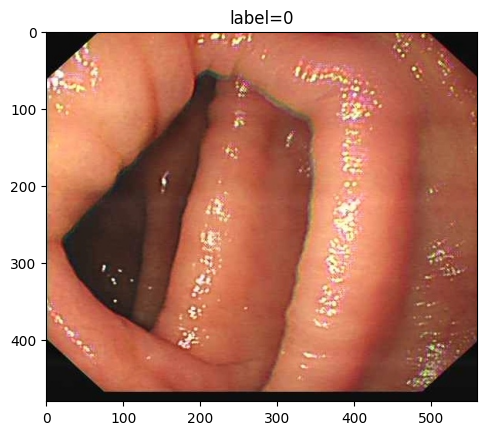

In [6]:
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

df = pd.read_csv("dataset/train.csv")
print(df.head())

row = df.iloc[0]
img = Image.open(row["image_path"])
plt.imshow(img)
plt.title(f"label={row['label']}")
plt.show()

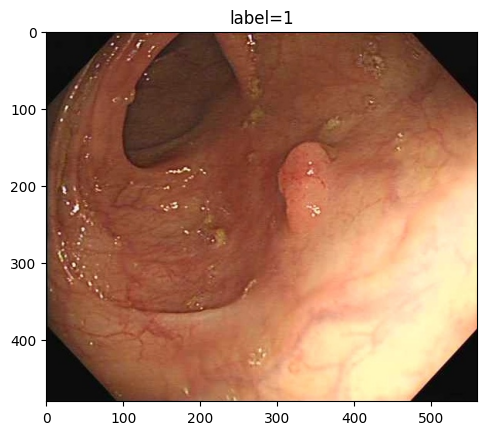

In [7]:
row = df.iloc[10]
img = Image.open(row["image_path"])
plt.imshow(img)
plt.title(f"label={row['label']}")
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   image_path       9871 non-null   object 
 1   annotation_path  9871 non-null   object 
 2   label            9871 non-null   int64  
 3   x1               8147 non-null   float64
 4   y1               8147 non-null   float64
 5   x2               8147 non-null   float64
 6   y2               8147 non-null   float64
 7   source_folder    9871 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 617.1+ KB


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

train = pd.read_csv("dataset/train.csv")
val = pd.read_csv("dataset/val.csv")
test = pd.read_csv("dataset/test.csv")

print(train.head())
print(train.info())

                 image_path                annotation_path  label     x1  \
0  Test\Images\124\0003.jpg  Test\Annotations\124\0003.txt      0    NaN   
1  Test\Images\147\0302.jpg  Test\Annotations\147\0302.txt      0    NaN   
2  Test\Images\123\0075.jpg  Test\Annotations\123\0075.txt      1  380.0   
3  Test\Images\115\0018.jpg  Test\Annotations\115\0018.txt      1  213.0   
4  Test\Images\140\0090.jpg  Test\Annotations\140\0090.txt      1   23.0   

      y1     x2     y2  source_folder  
0    NaN    NaN    NaN            124  
1    NaN    NaN    NaN            147  
2  125.0  445.0  216.0            123  
3  136.0  267.0  201.0            115  
4  198.0  162.0  463.0            140  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   image_path       9871 non-null   object 
 1   annotation_path  9871 non-null   object 
 2   label   


 train
label
1    8147
0    1724
Name: count, dtype: int64


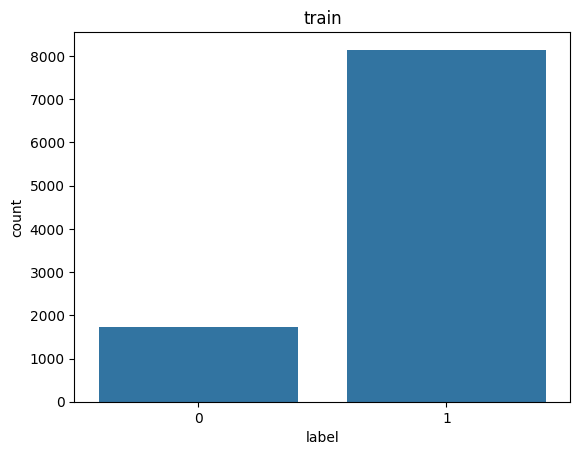


 val
label
1    1745
0     369
Name: count, dtype: int64


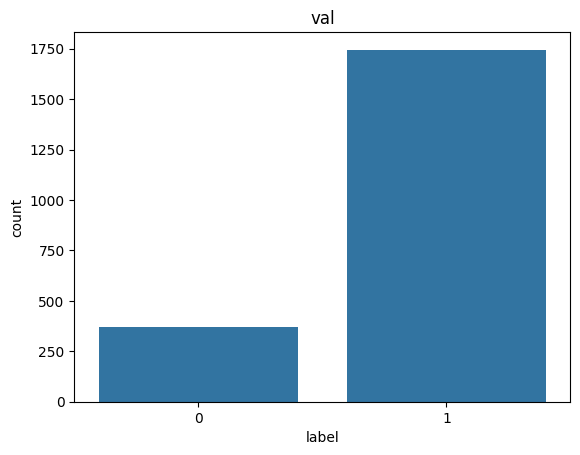


 test
label
1    1747
0     371
Name: count, dtype: int64


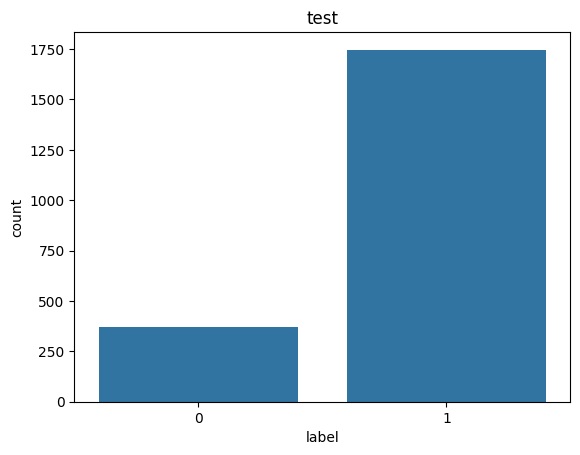

In [13]:
for name, df in [("train", train), ("val", val), ("test", test)]:
    print("\n", name)
    print(df["label"].value_counts())
    sns.countplot(data=df, x="label")
    plt.title(name)
    plt.show()

In [ ]:
# ths is really bad, the class imbalance is huge, we need to do some data augmentation or use a different dataset

                 w            h           area
count  8147.000000  8147.000000    8147.000000
mean     96.599116   103.151467   13762.180189
std      67.673699    70.048781   20732.868238
min      12.000000    15.000000     340.000000
25%      49.000000    53.000000    2752.000000
50%      75.000000    79.000000    5888.000000
75%     123.000000   134.000000   16402.000000
max     519.000000   474.000000  240297.000000


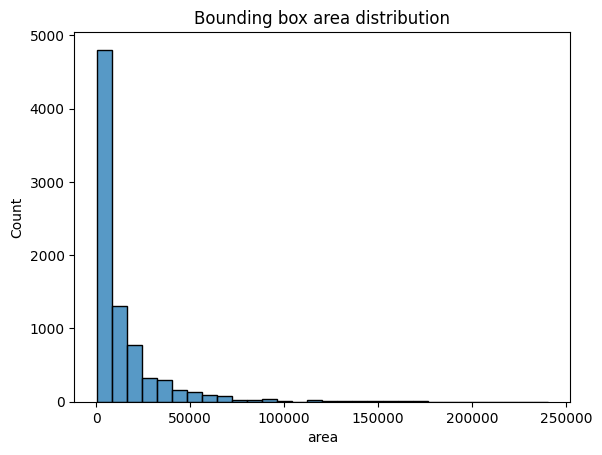

In [14]:
train["bbox_present"] = train["label"] == 1
train["x1"] = pd.to_numeric(train["x1"], errors="coerce")
train["y1"] = pd.to_numeric(train["y1"], errors="coerce")
train["x2"] = pd.to_numeric(train["x2"], errors="coerce")
train["y2"] = pd.to_numeric(train["y2"], errors="coerce")

pos = train[train["bbox_present"]].copy()
pos["w"] = pos["x2"] - pos["x1"]
pos["h"] = pos["y2"] - pos["y1"]
pos["area"] = pos["w"] * pos["h"]

print(pos[["w", "h", "area"]].describe())

sns.histplot(pos["area"], bins=30)
plt.title("Bounding box area distribution")
plt.show()

       width  height
count  200.0   200.0
mean   560.0   480.0
std      0.0     0.0
min    560.0   480.0
25%    560.0   480.0
50%    560.0   480.0
75%    560.0   480.0
max    560.0   480.0


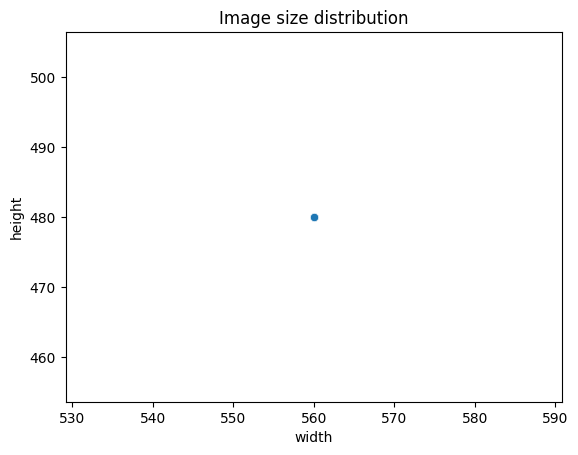

In [15]:
# image size considerations
sizes = []
for path in train["image_path"].head(200):
    img = Image.open(path)
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
print(sizes_df.describe())

sns.scatterplot(data=sizes_df, x="width", y="height")
plt.title("Image size distribution")
plt.show()

In [16]:
# good 

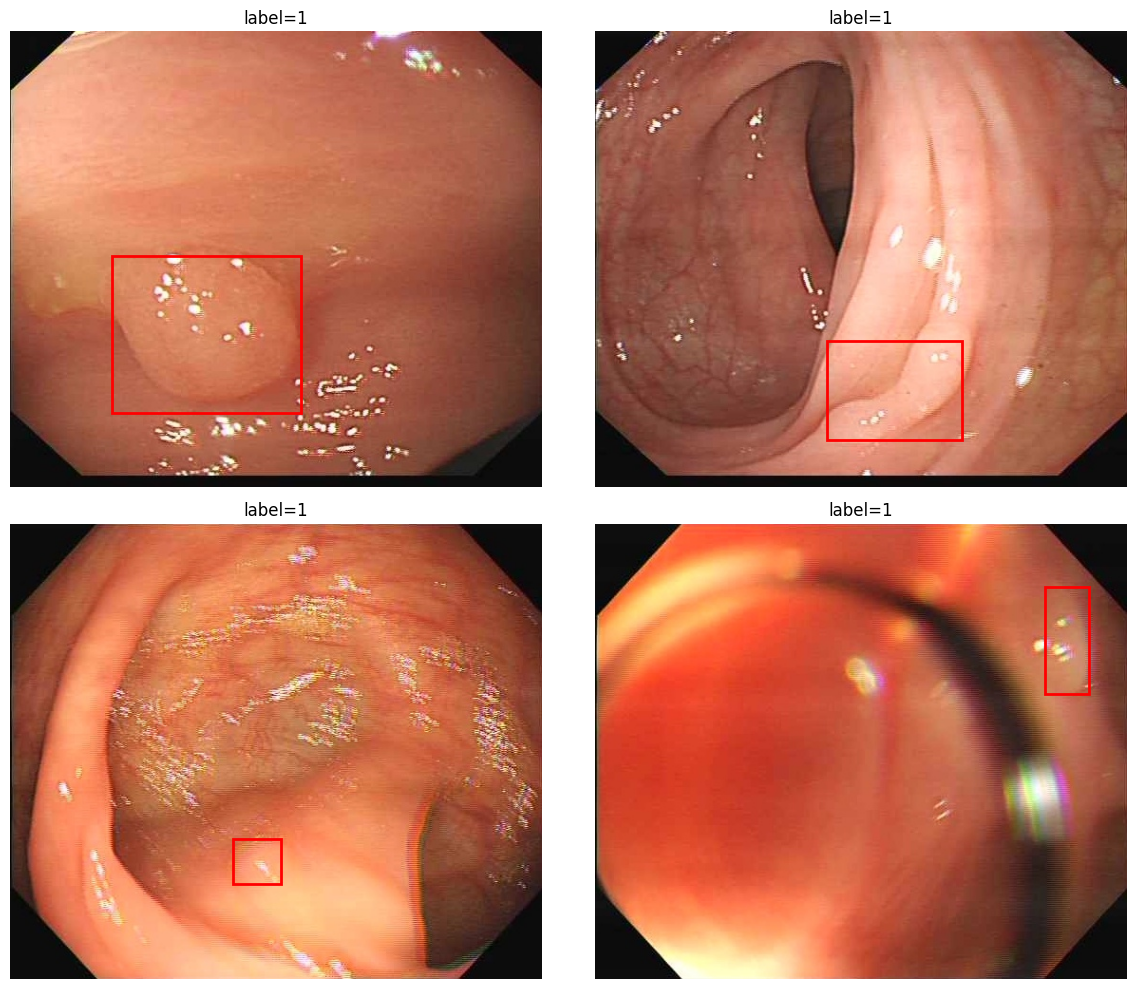

In [18]:
# checking samples
import matplotlib.patches as patches

sample = train.sample(4, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, row in zip(axes.flat, sample.itertuples()):
    img = Image.open(row.image_path).convert("RGB")
    ax.imshow(img)

    if row.label == 1:
        rect = patches.Rectangle(
            (row.x1, row.y1),
            row.x2 - row.x1,
            row.y2 - row.y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_title(f"label={row.label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
gan_data=train[train["label"] == 0]
gan_data

,image_path,annotation_path,label,x1,y1,x2,y2,source_folder
0,Test\Images\124\0003.jpg,Test\Annotations\124\0003.txt,0,NaN,NaN,NaN,NaN,124
1,Test\Images\147\0302.jpg,Test\Annotations\147\0302.txt,0,NaN,NaN,NaN,NaN,147
8,Test\Images\133\0197.jpg,Test\Annotations\133\0197.txt,0,NaN,NaN,NaN,NaN,133
23,Test\Images\136\0136.jpg,Test\Annotations\136\0136.txt,0,NaN,NaN,NaN,NaN,136
29,Test\Images\136\0277.jpg,Test\Annotations\136\0277.txt,0,NaN,NaN,NaN,NaN,136
...,...,...,...,...,...,...,...,...
9833,Test\Images\129\0011.jpg,Test\Annotations\129\0011.txt,0,NaN,NaN,NaN,NaN,129
9835,Test\Images\133\0195.jpg,Test\Annotations\133\0195.txt,0,NaN,NaN,NaN,NaN,133
9840,Test\Images\134\0006.jpg,Test\Annotations\134\0006.txt,0,NaN,NaN,NaN,NaN,134
9857,Test\Images\147\0343.jpg,Test\Annotations\147\0343.txt,0,NaN,NaN,NaN,NaN,147


In [13]:
gan_data.shape

(1724, 8)

In [17]:
# gan 
import torch
# from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import time
from IPython import display

In [1]:
# import torch
# import requests

# from PIL import Image
# from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

# url = 'http://images.cocodataset.org/val2017/000000039769.jpg' 
# image = Image.open(requests.get(url, stream=True).raw)

# image_processor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_r50vd")
# model = RTDetrForObjectDetection.from_pretrained("PekingU/rtdetr_r50vd")

# inputs = image_processor(images=image, return_tensors="pt")

# with torch.no_grad():
#     outputs = model(**inputs)

# results = image_processor.post_process_object_detection(outputs, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.3)

# for result in results:
#     for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
#         score, label = score.item(), label_id.item()
#         box = [round(i, 2) for i in box.tolist()]
#         print(f"{model.config.id2label[label]}: {score:.2f} {box}")
